In [1]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

print(df.head())

   order_id  order_date customer_name  gender    city product_name  \
0      1001  05-01-2026         Rahul    Male  Mumbai       Laptop   
1      1006  10-02-2026         Arjun    Male   Delhi       Laptop   
2      1002  08-01-2026          Aman    Male   Delhi       Mobile   
3      1007  15-02-2026         Sneha  Female  Mumbai       Mobile   
4      1010  10-03-2026        Anjali  Female   Delhi       Mobile   

      category  price  quantity  total_amount  
0  Electronics  55000         1         55000  
1  Electronics  55000         1         55000  
2  Electronics  25000         1         25000  
3  Electronics  25000         2         50000  
4  Electronics  25000         1         25000  


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       13 non-null     int64 
 1   order_date     13 non-null     object
 2   customer_name  13 non-null     object
 3   gender         13 non-null     object
 4   city           13 non-null     object
 5   product_name   13 non-null     object
 6   category       13 non-null     object
 7   price          13 non-null     int64 
 8   quantity       13 non-null     int64 
 9   total_amount   13 non-null     int64 
dtypes: int64(4), object(6)
memory usage: 1.1+ KB
None


In [3]:
print(df.isnull().sum())

order_id         0
order_date       0
customer_name    0
gender           0
city             0
product_name     0
category         0
price            0
quantity         0
total_amount     0
dtype: int64


In [4]:
print(df.describe())

          order_id         price   quantity  total_amount
count    13.000000     13.000000  13.000000     13.000000
mean   1005.230769  15953.846154   1.461538  18538.461538
std       3.031882  19780.150631   0.660225  21342.349857
min    1001.000000   1200.000000   1.000000   2000.000000
25%    1003.000000   2000.000000   1.000000   3600.000000
50%    1005.000000   5000.000000   1.000000   5000.000000
75%    1008.000000  25000.000000   2.000000  25000.000000
max    1010.000000  55000.000000   3.000000  55000.000000


In [5]:
print(df.duplicated().sum())

0


In [6]:
total_sales = df["total_amount"].sum()
print(total_sales)

241000


In [7]:
total_orders = df["order_id"].nunique()
print(total_orders)

10


In [8]:
total_custmers = df["customer_name"].nunique()
print(total_custmers)

8


In [9]:
category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Electronics    216000
Fashion         25000
Name: total_amount, dtype: int64


In [10]:
city_sales = (
    df.groupby("city")["total_amount"]
    .sum()
    .sort_values(ascending = False)
)

print(city_sales)

city
Mumbai    127400
Delhi     105000
Pune        8600
Name: total_amount, dtype: int64


In [11]:
product_sales = (
    df.groupby("product_name")["total_amount"]
    .sum()
    .sort_values(ascending = False)
)
print(product_sales)

product_name
Laptop        110000
Mobile        100000
Watch          10000
Shoes           9000
Headphones      6000
T-Shirt         6000
Name: total_amount, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

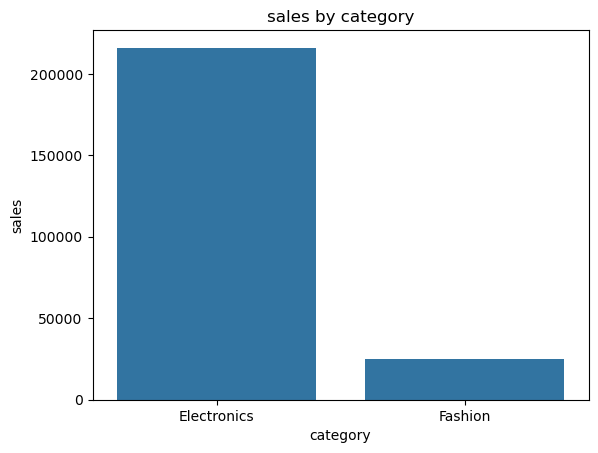

In [13]:
sns.barplot(
    x = category_sales.index,
    y = category_sales.values
)

plt.title("sales by category")
plt.xlabel("category")
plt.ylabel("sales")

plt.show()

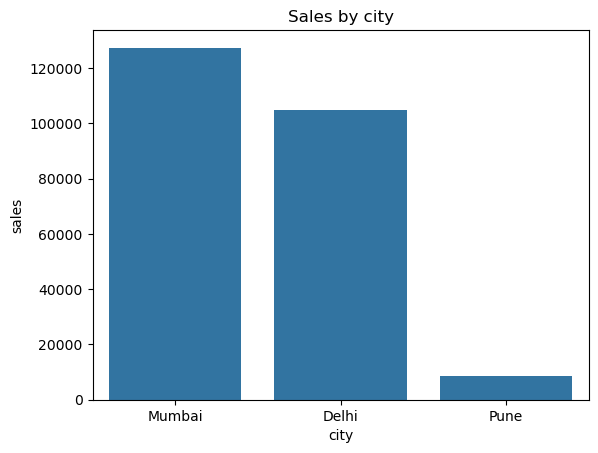

In [14]:
sns.barplot(
    x = city_sales.index,
    y = city_sales.values
)

plt.title("Sales by city")
plt.xlabel("city")
plt.ylabel("sales")

plt.show()

In [15]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

In [16]:
df["month"] = df["order_date"].dt.month

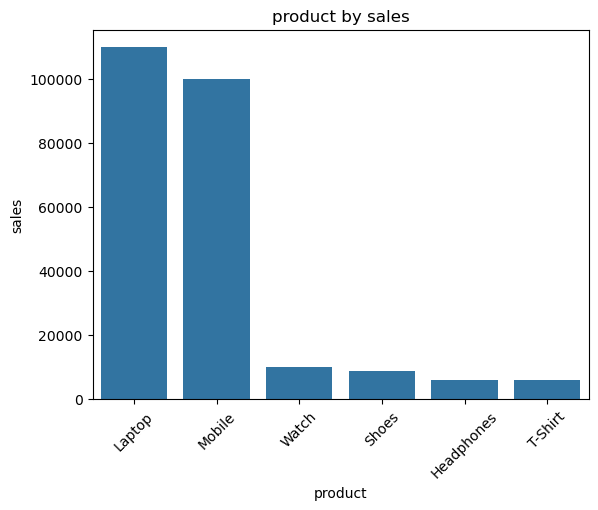

In [17]:
sns.barplot(
    x = product_sales.index,
    y = product_sales.values
)
plt.xticks(rotation=45)

plt.title("product by sales")
plt.xlabel("product")
plt.ylabel("sales")

plt.show()

In [18]:
monthly_sales = (
    df.groupby("month")["total_amount"]
    .sum()
)
print(monthly_sales)

month
1     97000
2    108600
3     35400
Name: total_amount, dtype: int64


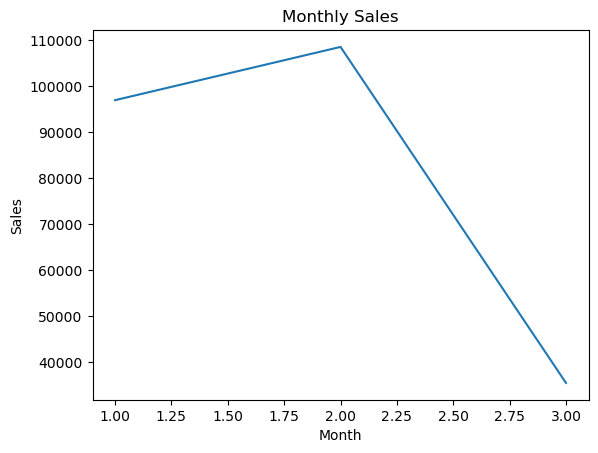

In [19]:
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()